# 01 Site Characterization and Hydrologic Context

Generates the wet/dry water-year comparison and low-flow precipitation sensitivity figures using the included precipitation, streamflow, storage, and groundwater datasets.


Average Water Year Total: 1959.82 mm
Annual Precipitation CV: 0.38
Complete Water Years used in calculation: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


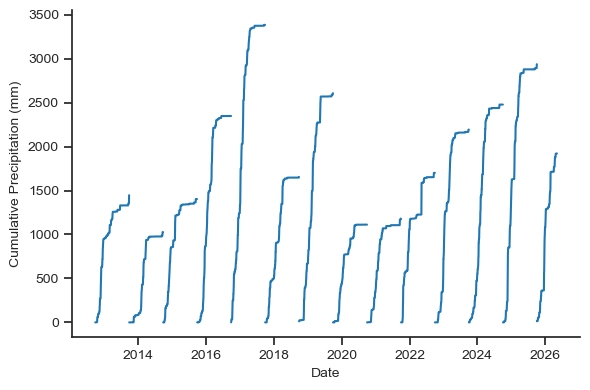

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
import re
import string
from scipy import stats as scipy_stats
from matplotlib.colors import ListedColormap

sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.grid': False
})

file_path = './Data/angelo_precip_5m.csv'
output_path = './Data/meadow_precip_daily.csv'

df = pd.read_csv(file_path, parse_dates=True, index_col=0)

precip = df[['angelo-meadow-ws-rainfall-combined-mm']].copy()
precip.columns = ['precip_mm']

precip = precip.resample('D').sum()

precip[['precip_mm']].to_csv(output_path)

precip['Water_Year'] = precip.index.year + (precip.index.month >= 10).astype(int)

wy_counts = precip.groupby('Water_Year')['precip_mm'].count()
complete_years = wy_counts[wy_counts >= 365].index.tolist()

wy_totals = precip[precip['Water_Year'].isin(complete_years)].groupby('Water_Year')['precip_mm'].sum()
avg_wy_total = wy_totals.mean()
cv_wy_total = wy_totals.std() / avg_wy_total

print(f"Average Water Year Total: {avg_wy_total:.2f} mm")
print(f"Annual Precipitation CV: {cv_wy_total:.2f}")
print(f"Complete Water Years used in calculation: {complete_years}")

precip['cumulative_precip_mm'] = precip.groupby('Water_Year')['precip_mm'].cumsum()

fig, ax = plt.subplots(figsize=(6, 4))

for year, group in precip.groupby('Water_Year'):
    ax.plot(group.index, group['cumulative_precip_mm'], color='tab:blue')

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Precipitation (mm)')

sns.despine()
plt.tight_layout()
plt.show()

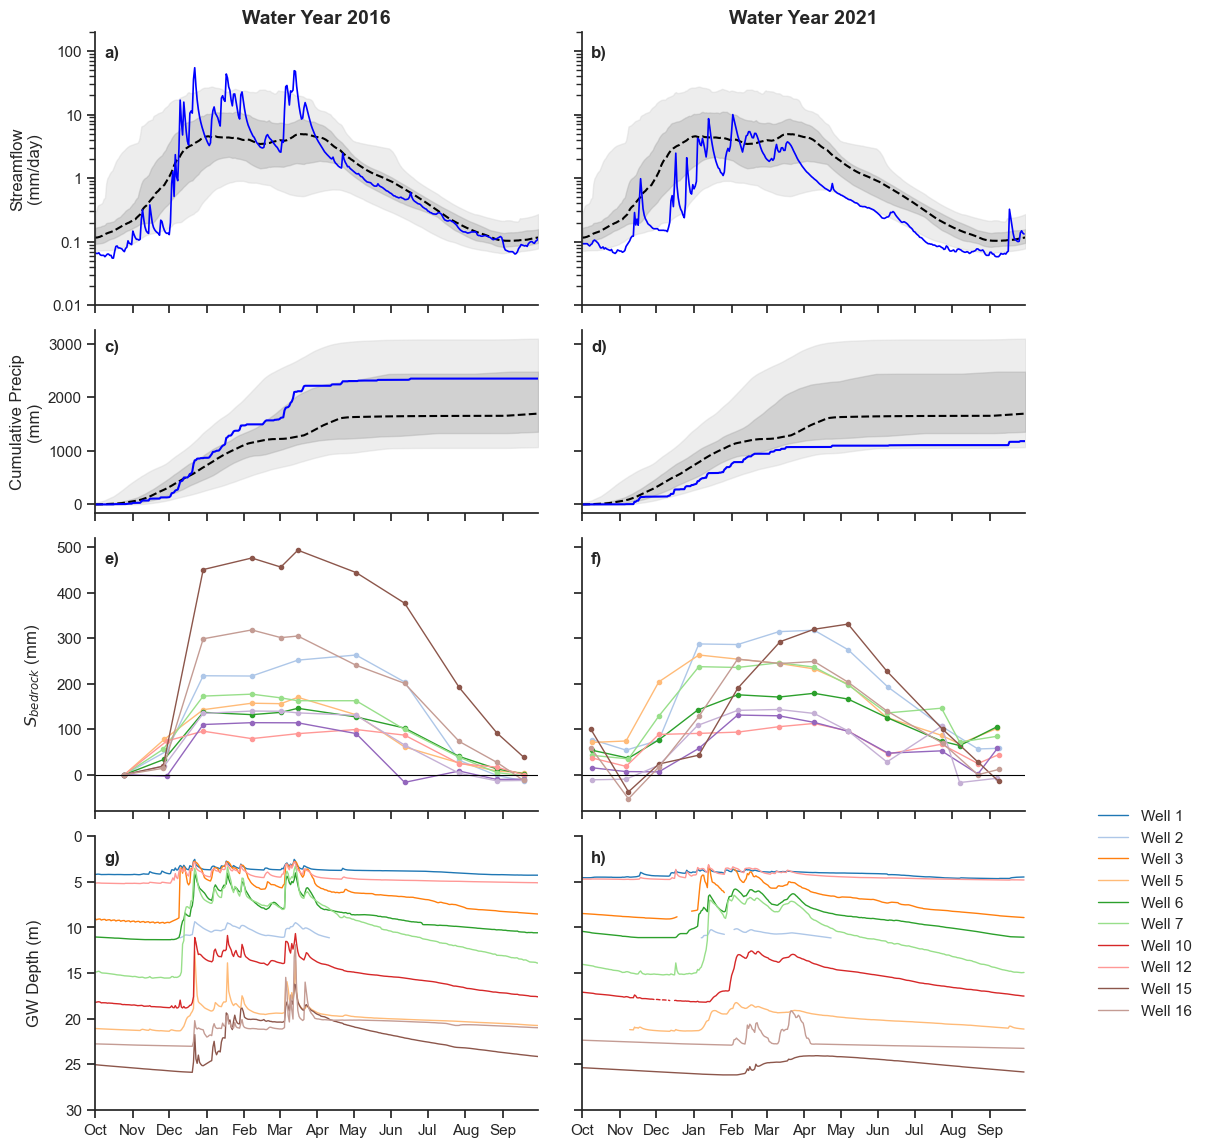

In [2]:
# --- Parameters & Paths ---
base_path = "./Data"
plots_dir = "./Plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

ppt_file = os.path.join(base_path, "meadow_precip_daily.csv")
flow_file = os.path.join(base_path, "elder_creek_clean.csv")
storage_file = os.path.join(base_path, "storage_ts.csv")
gw_file = os.path.join(base_path, "groundwater_hourly_resampled.csv")

# Defining the highlight years for the two columns
highlight_years = [2016, 2021]  # [Wet Year, Dry Year]

rolling_window_days = 30
font_size = 10

# Set global plotting styles
plt.rcParams.update({
    'font.size': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': 8
})
sns.set_theme(style="ticks")

def extract_well_num(name):
    nums = re.findall(r'\d+', str(name))
    return int(nums[0]) if nums else str(name)

# ==========================================
# 1. DATA LOADING & BACKGROUND STATS
# ==========================================
df_ppt = pd.read_csv(ppt_file, index_col=0, parse_dates=True)
df_flow = pd.read_csv(flow_file, index_col=0, parse_dates=True)
storage_ts = pd.read_csv(storage_file, parse_dates=['Date'])
df_gw = pd.read_csv(gw_file, index_col=0, parse_dates=True)

if df_flow.index.tz is not None:
    df_flow.index = df_flow.index.tz_localize(None)

# Join and prepare DOWY/WY for background stats
df_clim = df_ppt.join(df_flow, how='inner')
df_clim['WY'] = np.where(df_clim.index.month >= 10, df_clim.index.year + 1, df_clim.index.year)

def get_dowy(date):
    wy_start = pd.Timestamp(year=date.year if date.month >= 10 else date.year - 1, month=10, day=1)
    return (date - wy_start).days + 1

df_clim['DOWY'] = df_clim.index.map(get_dowy)
wy_counts = df_clim.groupby('WY').size()
complete_wys = wy_counts[wy_counts >= 365].index
df_clim = df_clim[df_clim['WY'].isin(complete_wys)].copy()

flow_pivot = df_clim.pivot(index='DOWY', columns='WY', values='flow_mm_day').reindex(range(1, 367))
ppt_pivot = df_clim.pivot(index='DOWY', columns='WY', values='precip_mm').reindex(range(1, 367)).fillna(0)
cum_ppt_pivot = ppt_pivot.cumsum()

# Background stats
stats = pd.DataFrame({
    'flow_p05': flow_pivot.quantile(0.05, axis=1),
    'flow_p25': flow_pivot.quantile(0.25, axis=1),
    'flow_p50': flow_pivot.median(axis=1),
    'flow_p75': flow_pivot.quantile(0.75, axis=1),
    'flow_p95': flow_pivot.quantile(0.95, axis=1),
    'ppt_p05': cum_ppt_pivot.quantile(0.05, axis=1),
    'ppt_p25': cum_ppt_pivot.quantile(0.25, axis=1),
    'ppt_p50': cum_ppt_pivot.median(axis=1),
    'ppt_p75': cum_ppt_pivot.quantile(0.75, axis=1),
    'ppt_p95': cum_ppt_pivot.quantile(0.95, axis=1)
}).rolling(window=rolling_window_days, center=True, min_periods=1).mean()

# ==========================================
# 2. MASTER COLOR MAPPING
# ==========================================
# Build a consistent color palette for all wells across all subplots
all_wells = set([extract_well_num(x) for x in storage_ts['Hole ID'].unique()])
all_wells.update([extract_well_num(c) for c in df_gw.columns if 'well' in str(c).lower()])
sorted_wells = sorted(list(all_wells), key=lambda x: int(x) if str(x).isdigit() else str(x))
well_color_map = dict(zip(sorted_wells, sns.color_palette("tab20", len(sorted_wells))))

# ==========================================
# 3. PLOTTING (4x2 GRID)
# ==========================================
fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex='col', sharey='row',
                         gridspec_kw={'height_ratios': [1.5, 1, 1.5, 1.5], 'hspace': 0.1, 'wspace': 0.1})

for col_idx, target_wy in enumerate(highlight_years):
    # Slice focal data for the specific Water Year
    start_dt = pd.Timestamp(f"{target_wy - 1}-10-01")
    end_dt = pd.Timestamp(f"{target_wy}-09-30")

    # Storage slice
    df_s_yr = storage_ts[(storage_ts['Date'] >= start_dt) & (storage_ts['Date'] <= end_dt)].copy()
    if not df_s_yr.empty:
        df_s_yr['DOWY_cont'] = (df_s_yr['Date'] - start_dt).dt.total_seconds() / 86400.0 + 1

    # GW slice (resampled to daily median to smooth and match DOWY scaling safely)
    df_gw_yr = df_gw.loc[start_dt:end_dt].resample('D').median()
    df_gw_yr['DOWY_cont'] = (df_gw_yr.index - start_dt).total_seconds() / 86400.0 + 1

    # Row 1: Streamflow
    ax_flow = axes[0, col_idx]
    ax_flow.fill_between(stats.index, stats['flow_p05'], stats['flow_p95'], color='lightgray', alpha=0.4)
    ax_flow.fill_between(stats.index, stats['flow_p25'], stats['flow_p75'], color='darkgray', alpha=0.4)
    ax_flow.plot(stats.index, stats['flow_p50'], color='black', linestyle='--', linewidth=1.5)
    if target_wy in flow_pivot.columns:
        ax_flow.plot(flow_pivot.index, flow_pivot[target_wy], color='blue', linewidth=1.2)
    ax_flow.set_yscale('log')
    ax_flow.set_ylim(0.01, 200)
    if col_idx == 0: ax_flow.set_ylabel('Streamflow\n(mm/day)')
    ax_flow.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

    # Set the Water Year as the column title instead of floating text
    ax_flow.set_title(f'Water Year {target_wy}', fontweight='bold', fontsize=14)

    # Row 2: Cumulative Precip
    ax_ppt = axes[1, col_idx]
    ax_ppt.fill_between(stats.index, stats['ppt_p05'], stats['ppt_p95'], color='lightgray', alpha=0.4)
    ax_ppt.fill_between(stats.index, stats['ppt_p25'], stats['ppt_p75'], color='darkgray', alpha=0.4)
    ax_ppt.plot(stats.index, stats['ppt_p50'], color='black', linestyle='--', linewidth=1.5)
    if target_wy in cum_ppt_pivot.columns:
        ax_ppt.plot(cum_ppt_pivot.index, cum_ppt_pivot[target_wy], color='blue', linewidth=1.5)
    if col_idx == 0: ax_ppt.set_ylabel('Cumulative Precip\n(mm)')

    # Row 3: Bedrock Storage
    ax_stor = axes[2, col_idx]
    if not df_s_yr.empty:
        for hole in sorted(df_s_yr['Hole ID'].unique(), key=extract_well_num):
            h_data = df_s_yr[df_s_yr['Hole ID'] == hole].sort_values('DOWY_cont')
            ax_stor.plot(h_data['DOWY_cont'], h_data['Total Storage Change (mm)'],
                         color=well_color_map[extract_well_num(hole)], marker='o', markersize=3, lw=1, label=f'Well {extract_well_num(hole)}')
    ax_stor.axhline(0, color='black', lw=0.8, ls='-')
    if col_idx == 0: ax_stor.set_ylabel(r'$S_{bedrock}$ (mm)')

    # Row 4: Groundwater Depth
    ax_gw = axes[3, col_idx]
    if not df_gw_yr.empty:
        gw_cols = [c for c in df_gw_yr.columns if c != 'DOWY_cont']
        for c in sorted(gw_cols, key=extract_well_num):
            ax_gw.plot(df_gw_yr['DOWY_cont'], -df_gw_yr[c],
                       color=well_color_map[extract_well_num(c)], lw=1, label=f'Well {extract_well_num(c)}')
    ax_gw.set_ylim(30, 0)
    if col_idx == 0: ax_gw.set_ylabel('GW Depth (m)')

    # X-axis formatting (Applies to the bottom row)
    dummy_dates = pd.date_range(start='2019-10-01', end='2020-09-30', freq='MS')
    month_dowy = [(d - pd.Timestamp('2019-10-01')).days + 1 for d in dummy_dates]
    ax_gw.set_xticks(month_dowy)
    ax_gw.set_xticklabels([d.strftime('%b') for d in dummy_dates])
    ax_gw.set_xlim(1, 366)

# Final cleanup
for ax in axes.flatten():
    ax.grid(False)
    sns.despine(ax=ax)

# ==========================================
# ADD SUBPLOT LETTERS (a, b, c, etc.)
# ==========================================
for i, ax in enumerate(axes.flatten()):
    letter = string.ascii_lowercase[i]
    ax.text(0.02, 0.95, f"{letter})", transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Unified well legend on the far right
handles, labels = axes[3, 0].get_legend_handles_labels()
if not handles: # Fallback if first year was empty
    handles, labels = axes[3, 1].get_legend_handles_labels()

by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='center right', bbox_to_anchor=(1.05, 0.25), frameon=False, ncol=1)

fig.align_ylabels(axes[:, 0])
plt.savefig(os.path.join(plots_dir, "wet_dry_comparison_4x2.png"), dpi=300, bbox_inches="tight")
plt.show()

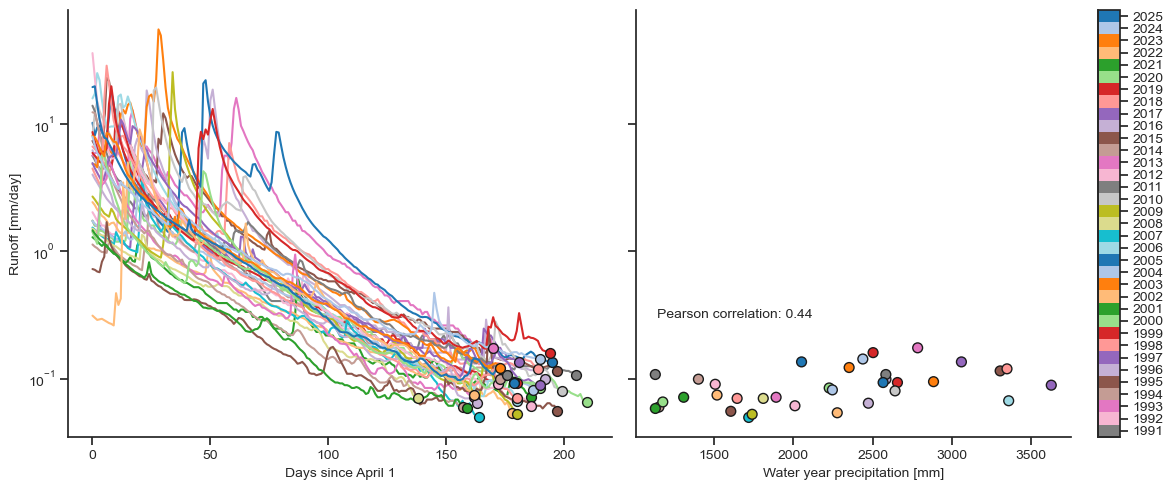

In [3]:
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

flow_path = './Data/elder_creek_clean.csv'
ppt_path = './Data/prism_ppt.csv'

flow = pd.read_csv(flow_path, index_col=0, parse_dates=True)
if flow.index.tz is not None:
    flow.index = flow.index.tz_localize(None)
flow = flow[['flow_mm_day']].rename(columns={'flow_mm_day': 'q'})
flow['wy'] = np.where(flow.index.month >= 10, flow.index.year + 1, flow.index.year)

rainfall = pd.read_csv(ppt_path, index_col=0, parse_dates=True)
if rainfall.index.tz is not None:
    rainfall.index = rainfall.index.tz_localize(None)
ppt_col = rainfall.columns[0]
rainfall = rainfall[[ppt_col]].rename(columns={ppt_col: 'ppt'})
rainfall['ppt'] = rainfall['ppt'] * 25.4
rainfall['wy'] = np.where(rainfall.index.month >= 10, rainfall.index.year + 1, rainfall.index.year)

years = sorted(list(set(flow['wy'].unique()) & set(rainfall['wy'].unique())))

# Remove 1990 due to incomplete precipitation data
years = [year for year in years if year != 1990]

wyrain = []
lowflow = []
surrogate = []
yearplot = []
lowflowdate = []

for year in years:
    wystart = f'{year-1}-10-01'
    wyend = f'{year}-09-30'
    sd = f'{year}-05-01'
    ed = f'{year}-12-01'
    apr1 = pd.to_datetime(f'{year}-04-01')

    try:
        q_slice = flow.loc[sd:ed, 'q']
        if q_slice.empty:
            continue

        q_min = q_slice.min()
        q_min_date = q_slice.idxmin()
        ppt_sum = rainfall.loc[wystart:wyend, 'ppt'].sum()

        wyrain.append(ppt_sum)
        lowflow.append(q_min)
        lowflowdate.append(q_min_date)
        yearplot.append(year)

        if q_min <= 1e-6:
            days_to_zero = (q_min_date - apr1).days
            surrogate.append(days_to_zero - 10000)
        else:
            surrogate.append(q_min)
    except Exception:
        continue

valid_indices = [i for i, (xi, yi) in enumerate(zip(wyrain, surrogate)) if np.isfinite(xi) and np.isfinite(yi)]

x = np.array([wyrain[i] for i in valid_indices])
y = np.array([lowflow[i] for i in valid_indices])
y_surrogate = np.array([surrogate[i] for i in valid_indices])
plot_years = [yearplot[i] for i in valid_indices]
plot_dates = [lowflowdate[i] for i in valid_indices]

if len(x) > 1:
    rho, p_value = scipy_stats.pearsonr(x, y_surrogate)

    f, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    cmap = ListedColormap(sns.color_palette('tab20', len(plot_years)).as_hex()).reversed()
    pal = np.flip(sns.color_palette('tab20', len(plot_years)).as_hex(), axis=0)

    ax = axs[1]
    sp = ax.scatter(x, y, c=plot_years, cmap=cmap, s=50, edgecolors='k')
    bounds = np.array([i for i in plot_years + [plot_years[-1] + 1]]) - 0.5
    cbar = plt.colorbar(sp, ax=ax, ticks=[i for i in plot_years if i % 1 == 0], boundaries=bounds)
    cbar.ax.tick_params(labelsize=10)

    ax.set_xlabel('Water year precipitation [mm]')
    ax.set_yscale('symlog', linthresh=0.001)
    ax.grid(False)

    ax.text(0.05, 0.3, f'Pearson correlation: {rho:.2f}', transform=ax.transAxes, va='top', ha='left')

    ax = axs[0]
    for i, year in enumerate(plot_years):
        sd = f'{year}-04-01'
        ed = plot_dates[i]
        try:
            toplot = flow.loc[sd:ed, 'q']
        except Exception:
            continue

        x_vals = range(len(toplot))
        ax.plot(x_vals, toplot, c=pal[i])
        ax.scatter(x_vals[-1], toplot.iloc[-1], c=pal[i], s=50, edgecolors='k', zorder=100)

    ax.set_ylabel('Runoff [mm/day]')
    ax.set_xlabel('Days since April 1')
    ax.set_yscale('symlog', linthresh=0.001)
    ax.grid(False)

    sns.despine()
    plt.tight_layout()
    plt.savefig('./Plots/low_flow_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()